In [5]:
import pandas as pd
import numpy as np
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                            classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("BASELINE MODELS - TRADITIONAL MACHINE LEARNING")

BASELINE MODELS - TRADITIONAL MACHINE LEARNING


# 1. LOAD DATA

In [8]:
import os

print("\n Loading preprocessed data")

data_paths = {
    "train": '../data/processed/train.csv',
    "val": '../data/processed/val.csv',
    "test": '../data/processed/test.csv',
    "label_encoder": '../models/label_encoder.pkl'
}

for key, path in data_paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f" {key} file not found at {path}")


train_df = pd.read_csv(data_paths["train"])
val_df = pd.read_csv(data_paths["val"])
test_df = pd.read_csv(data_paths["test"])

required_cols = ['text', 'label']
for df_name, df_data in zip(['train', 'val', 'test'], [train_df, val_df, test_df]):
    missing = set(required_cols) - set(df_data.columns)
    if missing:
        raise ValueError(f" {df_name} dataset is missing columns: {missing}")


print(f" Train: {len(train_df)} samples")
print(f" Val:   {len(val_df)} samples")
print(f" Test:  {len(test_df)} samples")

print("\n Sample data (train):")
print(train_df.head(3))

# Load label encoder
with open(data_paths["label_encoder"], 'rb') as f:
    label_encoder = pickle.load(f)

print("\n Label encoder loaded")
print(f" Classes: {list(label_encoder.classes_)}")


 Loading preprocessed data
 Train: 35199 samples
 Val:   7519 samples
 Test:  7539 samples

 Sample data (train):
                                                text  label
0  nurse night shift hi everyone im no sure id lo...      1
1  fuck bitch make life hell get kicked manage pl...      5
2  run weed thing kept going hade horrible day ye...      6

 Label encoder loaded
 Classes: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']


# 2. FEATURE EXTRACTION

In [17]:
print("\nExtracting features")

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_params = {
    'max_features': 5000,
    'ngram_range': (1, 2),
    'stop_words': None,  # Already removed in preprocessing
}

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(**tfidf_params)

X_train_tfidf = tfidf.fit_transform(train_df['text'])
X_val_tfidf = tfidf.transform(val_df['text'])
X_test_tfidf = tfidf.transform(test_df['text'])

y_train = train_df['label'].values
y_val = val_df['label'].values
y_test = test_df['label'].values

print(f"  TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"  Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"  Sample features: {list(tfidf.vocabulary_.keys())[:10]}")

# Save vectorizer 
import pickle
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("TF-IDF vectorizer saved: models/tfidf_vectorizer.pkl")


Extracting features
  TF-IDF feature shape: (35199, 5000)
  Vocabulary size: 5000
  Sample features: ['nurse', 'night', 'shift', 'hi', 'everyone', 'im', 'no', 'sure', 'id', 'love']
TF-IDF vectorizer saved: models/tfidf_vectorizer.pkl


# 3. TRAIN BASELINE MODELS

In [24]:
print("\n Training baseline models")

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Naive Bayes': MultinomialNB(), 
    'SVM': LinearSVC(
        random_state=42, max_iter=3000, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train_tfidf, y_train)
    
    # Validation prediction
    y_val_pred = model.predict(X_val_tfidf)
    
    # Metrics
    accuracy = accuracy_score(y_val, y_val_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_val, y_val_pred, average='weighted'
    )
    
    # Confusion matrix
    cm = confusion_matrix(y_val, y_val_pred)
    
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'model': model,
        'predictions': y_val_pred
    }
    
    print(f"    Accuracy : {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall   : {recall:.4f}")
    print(f"    F1-Score : {f1:.4f}")
    
    # Save model
    model_filename = f"../models/{name.lower().replace(' ', '_')}.pkl"
    with open(model_filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"   Model saved: {model_filename}")


 Training baseline models

Training Logistic Regression...
    Accuracy : 0.7460
    Precision: 0.7560
    Recall   : 0.7460
    F1-Score : 0.7466
   Model saved: ../models/logistic_regression.pkl

Training Naive Bayes...
    Accuracy : 0.6793
    Precision: 0.7004
    Recall   : 0.6793
    F1-Score : 0.6625
   Model saved: ../models/naive_bayes.pkl

Training SVM...
    Accuracy : 0.7405
    Precision: 0.7399
    Recall   : 0.7405
    F1-Score : 0.7388
   Model saved: ../models/svm.pkl

Training Random Forest...
    Accuracy : 0.7200
    Precision: 0.7362
    Recall   : 0.7200
    F1-Score : 0.7067
   Model saved: ../models/random_forest.pkl


# 4. RESULTS COMPARISON


Comparing model performance

Model Comparison (Validation Set):
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.745977   0.755988 0.745977  0.746561
                SVM  0.740524   0.739934 0.740524  0.738827
      Random Forest  0.720043   0.736206 0.720043  0.706663
        Naive Bayes  0.679346   0.700421 0.679346  0.662451

 Best Baseline Model (Validation Set): Logistic Regression
   F1-Score: 0.7466

✓ Saved: results/figures/06_baseline_comparison.png


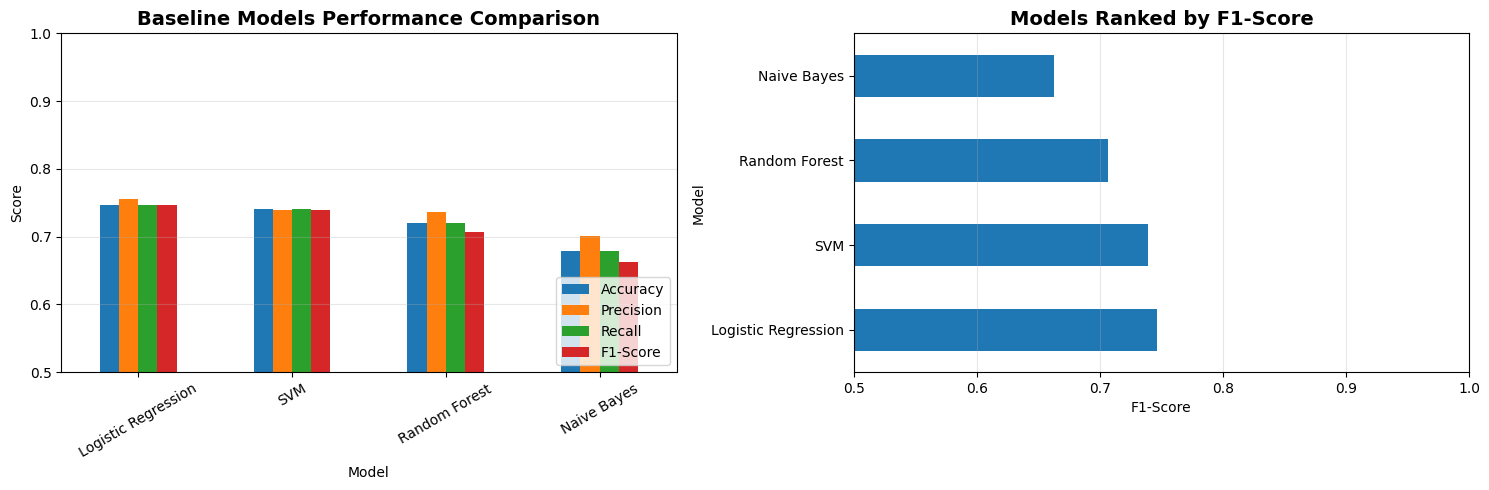

In [29]:
print("\nComparing model performance")

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'F1-Score': [results[m]['f1'] for m in results.keys()]
})

# Sort models by F1-score 
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("\nModel Comparison (Validation Set):")
print(comparison_df.to_string(index=False))

# Identify best-performing model
best_model_name = comparison_df.iloc[0]['Model']
best_f1 = comparison_df.iloc[0]['F1-Score']

print(f"\n Best Baseline Model (Validation Set): {best_model_name}")
print(f"   F1-Score: {best_f1:.4f}")


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart 
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], rot=30
)
axes[0].set_title('Baseline Models Performance Comparison', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Horizontal bar chart for F1-score ranking
comparison_df.plot(
    x='Model', y='F1-Score', kind='barh', ax=axes[1], legend=False
)
axes[1].set_title('Models Ranked by F1-Score', fontweight='bold', fontsize=14)
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0.5, 1.0)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/06_baseline_comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/figures/06_baseline_comparison.png")
plt.show()

# 5. DETAILED ANALYSIS OF BEST MODEL


 Analyzing best performing model

 Best Model: Logistic Regression
   Validation F1-Score: 0.7466

 Detailed Classification Report (Validation Set):
                      precision    recall  f1-score   support

             Anxiety       0.77      0.81      0.79       539
             Bipolar       0.74      0.78      0.76       374
          Depression       0.77      0.61      0.68      2254
              Normal       0.87      0.90      0.89      2285
Personality disorder       0.48      0.74      0.58       134
              Stress       0.46      0.66      0.54       343
            Suicidal       0.66      0.71      0.68      1590

            accuracy                           0.75      7519
           macro avg       0.68      0.74      0.70      7519
        weighted avg       0.76      0.75      0.75      7519

 Saved: results/metrics/baseline_classification_report.txt
 Saved: results/figures/07_baseline_confusion_matrix.png


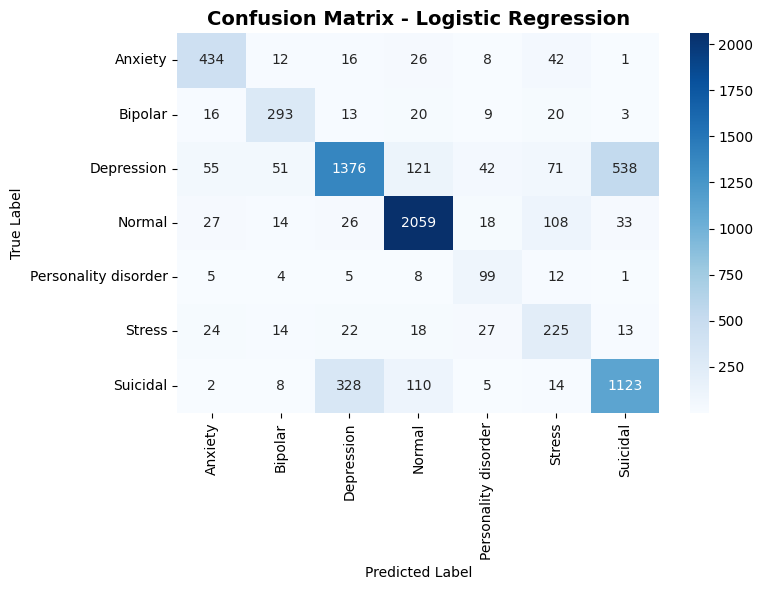

 Saved: results/figures/08_baseline_confusion_matrix_normalized.png


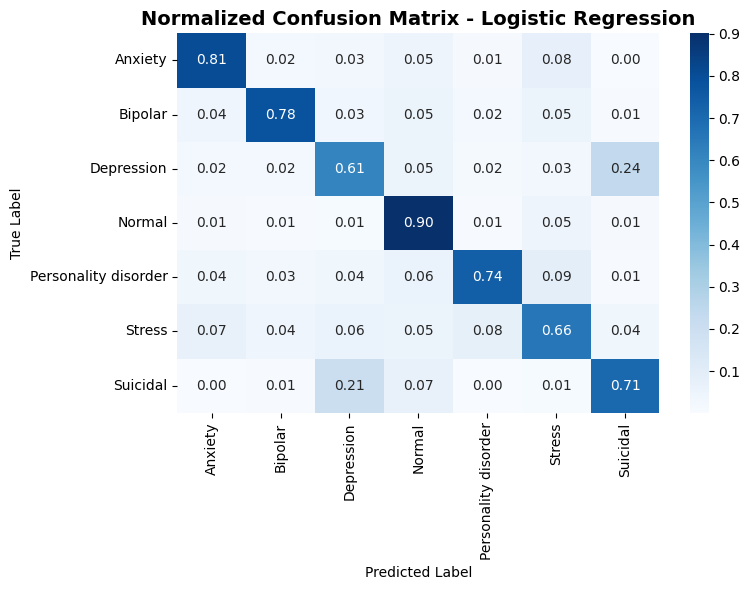


 Evaluating on Test Set...
  Accuracy : 0.7396
  Precision: 0.7520
  Recall   : 0.7396
  F1-Score : 0.7403

Saved best model: models/best_baseline_model.pkl
 Saved vectorizer: models/tfidf_vectorizer.pkl
 Saved: results/metrics/baseline_results.json
 BASELINE MODELS COMPLETE!

 Best Baseline Model: Logistic Regression
   Validation F1-Score: 0.7466
   Test F1-Score      : 0.7403


In [36]:
print("\n Analyzing best performing model")

best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n Best Model: {best_model_name}")
print(f"   Validation F1-Score: {results[best_model_name]['f1']:.4f}")

# CLASSIFICATION REPORT
print(f"\n Detailed Classification Report (Validation Set):")

report = classification_report(
    y_val,
    best_predictions,
    target_names=label_encoder.classes_,
    zero_division=0
)
print(report)

with open('../results/metrics/baseline_classification_report.txt', 'w') as f:
    f.write(report)
print(" Saved: results/metrics/baseline_classification_report.txt")


# CONFUSION MATRIX (RAW COUNTS)
cm = confusion_matrix(y_val, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/figures/07_baseline_confusion_matrix.png', dpi=300)
print(" Saved: results/figures/07_baseline_confusion_matrix.png")
plt.show()

# NORMALIZED CONFUSION MATRIX
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title(f'Normalized Confusion Matrix - {best_model_name}',
          fontweight='bold', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/figures/08_baseline_confusion_matrix_normalized.png', dpi=300)
print(" Saved: results/figures/08_baseline_confusion_matrix_normalized.png")
plt.show()


# TEST SET EVALUATION
print(f"\n Evaluating on Test Set...")

y_test_pred = best_model.predict(X_test_tfidf)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_test,
    y_test_pred,
    average='weighted',
    zero_division=0
)

print(f"  Accuracy : {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall   : {test_recall:.4f}")
print(f"  F1-Score : {test_f1:.4f}")


# SAVING BEST MODEL & VECTORIZER
with open('../models/best_baseline_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("\nSaved best model: models/best_baseline_model.pkl")
print(" Saved vectorizer: models/tfidf_vectorizer.pkl")


# SAVING METRICS
baseline_results = {
    'models': {
        name: {
            'accuracy': float(results[name]['accuracy']),
            'precision': float(results[name]['precision']),
            'recall': float(results[name]['recall']),
            'f1': float(results[name]['f1'])
        }
        for name in results.keys()
    },
    'best_model': best_model_name,
    'test_results': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1)
    }
}

import json
with open('../results/metrics/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

print(" Saved: results/metrics/baseline_results.json")

print(" BASELINE MODELS COMPLETE!")
print(f"\n Best Baseline Model: {best_model_name}")
print(f"   Validation F1-Score: {results[best_model_name]['f1']:.4f}")
print(f"   Test F1-Score      : {test_f1:.4f}")
